## 1 · Imports

In [1]:
from anndata import AnnData
from typing import Optional

# Libraries
import anndata as ad
import matplotlib as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.pyplot import rc_context
from scipy.stats import median_abs_deviation

from functools import partial
import altair as alt
import seaborn as sns
import decoupler as dc
from scipy.sparse import csr_matrix
import os
from pathlib import Path

import mudata as mu
import scanpy as sc
import scirpy as ir
import altair as alt
alt.data_transformers.enable("vegafusion")

import anndata as ad
import numpy as np
import palantir

import numpy as np
import scipy.sparse as sp

In [2]:
import muon as mu
from muon import MuData

2026-06-02 10:04:56.402946: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-02 10:04:56.840709: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2 · Data Loading

Load mudata

In [3]:
mdata = mu.read_h5mu("/data/projects/2021/MicrobialMetabolites/single-cell-sorted-cd8/results/40_gex_surface_prot/003_trajectory_annotated_mudata.h5mu")

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/anndata/utils.py:354: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adop

In [4]:
rename_dict = {
    "10mix_ICI1": "ctrl1",
    "10mix_ICI2": "ctrl2",
    "11mix_ICI1": "effector1",
    "11mix_ICI2": "effector2",
    "GF_ICI1": "GF_noici1",
    "GF_ICI2": "GF_noici2",
    "GF_ICI1_plus": "GF1",
    "GF_ICI2_plus": "GF2"
}

mdata["gex"].obs["sample_id"] = (
    mdata["gex"].obs["sample_id"]
    .replace(rename_dict)
)

/tmp/ipykernel_827360/2077462208.py:14: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  .replace(rename_dict)


In [5]:
mask = ~mdata["gex"].obs["cell_annotation_05"].isin(["Cycling"])

mdata_without_cycling = mdata[mask, :].copy()

/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/kvalem/.conda/envs/scvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## 3 · Pseudobulk for DGSEA

Running it on mdata_without_cycling for DGSEA we want to avoid the cycling genes that could be misleading

In [16]:
mdata["gex"].obs["all_cd8"] = "all"

pdata = dc.pp.pseudobulk(
    adata=mdata_without_cycling["gex"],
    sample_col="sample_id",
    groups_col=["all_cd8"],   
    mode="sum",
    empty=False,
    layer="counts",
)

/tmp/ipykernel_390315/741083822.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["all_cd8"] = "all"


In [19]:
pdata

AnnData object with n_obs × n_vars = 8 × 17581
    obs: 'sample_id', 'all_cd8', 'adata_name', 'condition', 'batch_id', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'is_outlier', 'mt_outlier', 'treatment', 'group4', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    layers: 'psbulk_props'

In [18]:
#pdata.write_h5ad("pdata.h5ad")

In [18]:
sc.tl.pca(pdata)

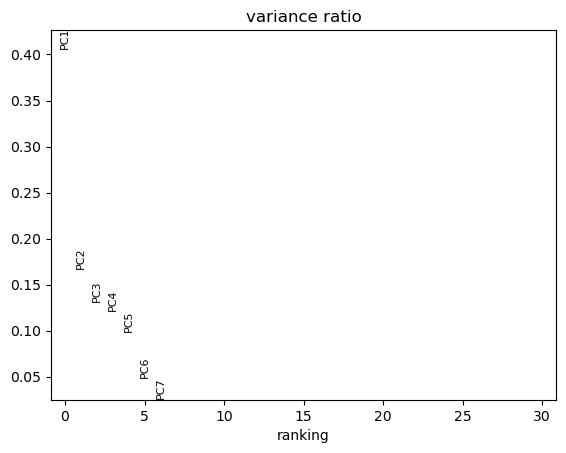

In [19]:
sc.pl.pca_variance_ratio(pdata)

In [20]:
pdata

AnnData object with n_obs × n_vars = 8 × 17581
    obs: 'sample_id', 'all_cd8', 'adata_name', 'condition', 'batch_id', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'is_outlier', 'mt_outlier', 'treatment', 'group4', 'psbulk_cells', 'psbulk_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mito', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'n_cells'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'psbulk_props'

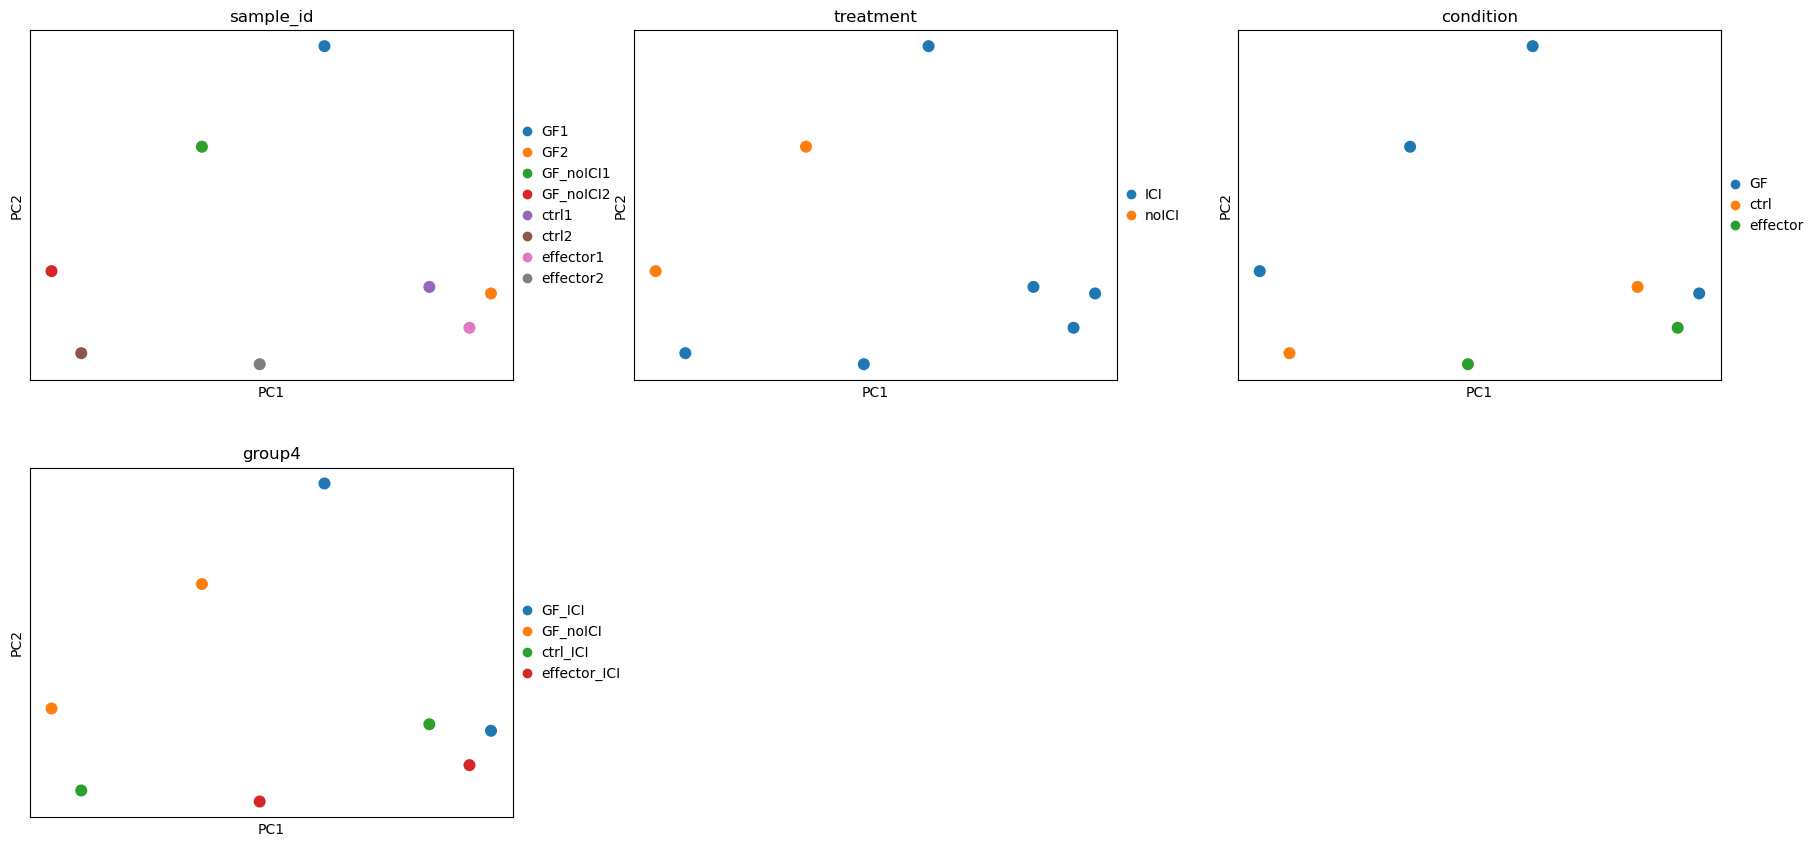

In [21]:
sc.pl.pca(
    pdata,
    color=["sample_id", "treatment", "condition","group4"],#,"cell_annotation_05"],
    ncols=3,
    size=300,
    frameon=True,
)

In [22]:
group_map = {
    "ctrl1": "ctrl_ICI",
    "ctrl2": "ctrl_ICI",
    "effector1": "effector_ICI",
    "effector2": "effector_ICI",
    "GF_noICI1": "GF_noICI",
    "GF_noICI2": "GF_noICI",
    "GF1": "GF_ICI",
    "GF2": "GF_ICI",
}

# pdata.obs contains sample_id and cell_annotation_05 after pseudobulk
pdata.obs["group4"] = pdata.obs["sample_id"].map(group_map).astype("category")

# sanity check
print(pdata.obs["group4"].value_counts(dropna=False))

group4
GF_ICI          2
GF_noICI        2
ctrl_ICI        2
effector_ICI    2
Name: count, dtype: int64


In [24]:
# convert to array if sparse
counts = pdata.X

if not isinstance(counts, np.ndarray):
    counts = counts.toarray()

# keep genes with >=10 counts in at least 2 samples
gene_filter = (counts >= 10).sum(axis=0) >= 2

pdata_filtered = pdata[:, gene_filter].copy()

print("Genes before filtering:", pdata.shape[1])
print("Genes after filtering:", pdata_filtered.shape[1])

Genes before filtering: 17581
Genes after filtering: 14230


In [ ]:
from scipy import sparse

In [25]:
samplesheet = pdata_filtered.obs.copy()
samplesheet.insert(0, "sample", pdata_filtered.obs_names)

samplesheet.to_csv("samplesheet.csv", index=False)

X = pdata_filtered.X

if sparse.issparse(X):
    counts_array = X.toarray()
else:
    counts_array = np.asarray(X)

# genes as rows, samples as columns
counts_df = pd.DataFrame(
    counts_array.T,
    index=pdata_filtered.var_names,   # gene_name
    columns=pdata_filtered.obs_names
)


gene_id = pdata_filtered.var["gene_ids"].values      # ENSG...
gene_name = pdata_filtered.var_names.values          # gene symbols

# insert in correct order
counts_df.insert(0, "gene_name", gene_name)
counts_df.insert(0, "gene_id", gene_id)

# optional: ensure integer counts
counts_df.iloc[:, 2:] = counts_df.iloc[:, 2:].round().astype(int)

counts_df.columns = [
    col.replace("_all", "") if col not in ["gene_id", "gene_name"] else col
    for col in counts_df.columns
]

# save
counts_df.to_csv("counts_matrix.tsv", sep="\t", index=False)

## 4 · Pseudobulk for cytosig

In [16]:
mdata_without_cycling["gex"].obs["all_cd8"] = "all"

pdata = dc.pp.pseudobulk(
    adata=mdata["gex"],
    sample_col="sample_id",
    groups_col=["all_cd8"],   
    mode="sum",
    empty=False,
    layer="counts",
)

/tmp/ipykernel_390315/741083822.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["all_cd8"] = "all"


In [18]:
#pdata.write_h5ad("pdata_cytosig.h5ad")

In [16]:
mdata_without_cycling["gex"].obs["all_cd8"] = "all"

pdata = dc.pp.pseudobulk(
    adata=mdata_without_cycling["gex"],
    sample_col="sample_id",
    groups_col=["all_cd8"],   
    mode="sum",
    empty=False,
    layer="counts",
)

/tmp/ipykernel_390315/741083822.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["all_cd8"] = "all"


In [18]:
#pdata.write_h5ad("pdata_cytosig_without_cycling.h5ad")